In [1]:
# Step 1: Environment Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Version Table
versions = pd.DataFrame({
    "Library": ["NumPy", "Pandas", "Matplotlib", "Seaborn"],
    "Version": [
        np.__version__,
        pd.__version__,
        plt.matplotlib.__version__,
        sns.__version__
    ]
})

print("Environment Verification Table")
print("="*50)
print(versions)

Environment Verification Table
      Library Version
0       NumPy   2.0.2
1      Pandas   2.3.3
2  Matplotlib  3.10.0
3     Seaborn  0.13.2


In [2]:
# Load dataset
df = pd.read_csv("/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv")

# First 10 rows
print("="*60)
print("FIRST 10 ROWS")
print(df.head(10))

FIRST 10 ROWS
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2    

In [3]:
# Last 5 rows
print("="*60)
print("LAST 5 ROWS")
print(df.tail(5))

LAST 5 ROWS
     gender race/ethnicity parental level of education         lunch  \
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
995               completed          88             99             95  
996                    none          62             55             55  
997               completed          59             71             65  
998               completed          68             78             77  
999                    none          77             86             86  


In [4]:
# Random sample
print("="*60)
print("RANDOM SAMPLE OF 8 ROWS")
print(df.sample(8, random_state=42))

RANDOM SAMPLE OF 8 ROWS
     gender race/ethnicity parental level of education         lunch  \
521  female        group C          associate's degree      standard   
737  female        group B                some college  free/reduced   
740    male        group D           bachelor's degree      standard   
660    male        group C                some college  free/reduced   
411    male        group E                some college      standard   
678    male        group D          associate's degree  free/reduced   
626    male        group B          associate's degree  free/reduced   
513  female        group B            some high school      standard   

    test preparation course  math score  reading score  writing score  
521                    none          91             86             84  
737               completed          53             66             73  
740                    none          80             73             72  
660                    none          74

Each row represents one student.
Each column represents demographic information or exam scores.
The dataset contains student background variables and academic performance scores.

## Step 3 — Dataset Structure Analysis

In [5]:
print("="*60)
print("Dataset Shape")
print(df.shape)

Dataset Shape
(1000, 8)


In [6]:
print("="*60)
print("Data Types")
print(df.dtypes)

Data Types
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [7]:
print("="*60)
print("Dataset Info")
print(df.info())

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [8]:
print("="*60)
print("Column Names")
print(df.columns.tolist())

Column Names
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


## Count categorical & numerical columns

In [9]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=np.number).columns

print("Categorical Columns:", len(categorical_cols))
print(categorical_cols)

print("Numerical Columns:", len(numerical_cols))
print(numerical_cols)

Categorical Columns: 5
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')
Numerical Columns: 3
Index(['math score', 'reading score', 'writing score'], dtype='object')


## Step 4 — Missing Value & Duplicate Analysis

In [10]:
# Missing values
missing_values = df.isnull().sum()

print("Missing Values Per Column")
print(missing_values)

Missing Values Per Column
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [11]:
# Missing percentages
missing_percentage = (df.isnull().sum()/len(df))*100
print("\nMissing Percentage")
print(missing_percentage)

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())


Missing Percentage
gender                         0.0
race/ethnicity                 0.0
parental level of education    0.0
lunch                          0.0
test preparation course        0.0
math score                     0.0
reading score                  0.0
writing score                  0.0
dtype: float64

Duplicate Rows: 0


## Missing Values Bar Chart

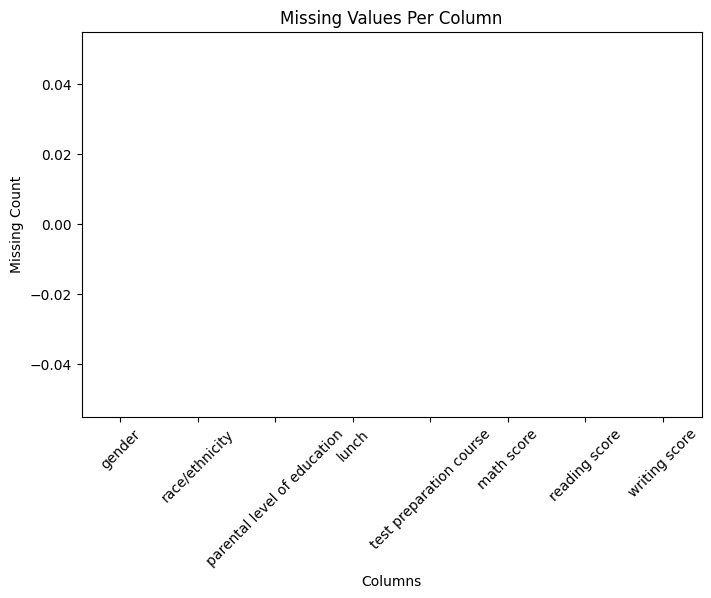

In [12]:
plt.figure(figsize=(8,5))
missing_values.plot(kind='bar')
plt.title("Missing Values Per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.show()

## Step 5 — Descriptive Statistics

In [13]:
print(df.describe())

       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


In [14]:
score_cols = ['math score', 'reading score', 'writing score']

stats = {}

for col in score_cols:
    stats[col] = {
        "Mean": df[col].mean(),
        "Median": df[col].median(),
        "Mode": df[col].mode()[0],
        "Std Dev": df[col].std(),
        "Variance": df[col].var(),
        "Min": df[col].min(),
        "Max": df[col].max(),
        "Range": df[col].max() - df[col].min()
    }

stats_df = pd.DataFrame(stats).T
print(stats_df)

                 Mean  Median  Mode    Std Dev    Variance   Min    Max  Range
math score     66.089    66.0  65.0  15.163080  229.918998   0.0  100.0  100.0
reading score  69.169    70.0  72.0  14.600192  213.165605  17.0  100.0   83.0
writing score  68.054    69.0  74.0  15.195657  230.907992  10.0  100.0   90.0


## Step 6 — Categorical Distribution Analysis

In [15]:
cat_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

for col in cat_cols:
    print("="*60)
    print(f"Value Counts: {col}")
    print(df[col].value_counts())
    
    print("\nPercentage Distribution")
    print(df[col].value_counts(normalize=True)*100)

Value Counts: gender
gender
female    518
male      482
Name: count, dtype: int64

Percentage Distribution
gender
female    51.8
male      48.2
Name: proportion, dtype: float64
Value Counts: race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Percentage Distribution
race/ethnicity
group C    31.9
group D    26.2
group B    19.0
group E    14.0
group A     8.9
Name: proportion, dtype: float64
Value Counts: parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Percentage Distribution
parental level of education
some college          22.6
associate's degree    22.2
high school           19.6
some high school      17.9
bachelor's degree     11.8
master's degree        5.9
Name: proportion, dtype: float64
Value Counts: lunch
lunch

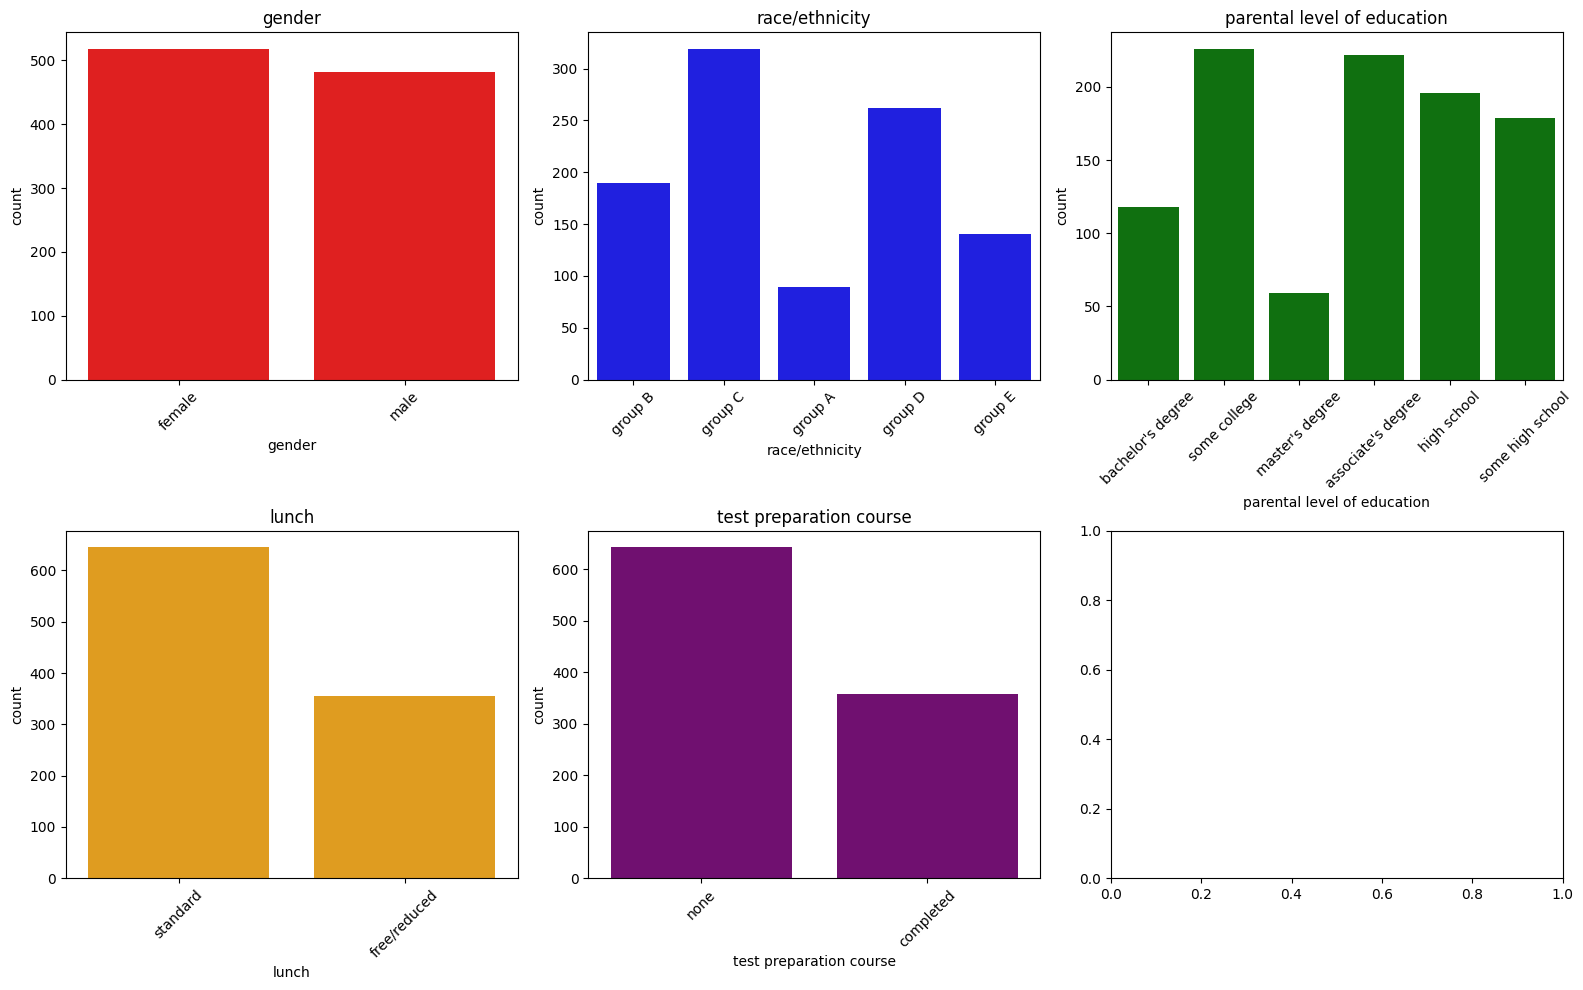

In [16]:
fig, axes = plt.subplots(2,3, figsize=(16,10))
axes = axes.flatten()

colors = ['red','blue','green','orange','purple']

for i,col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], color=colors[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Step 7 — Group Mean Score Comparisons

In [17]:
for col in cat_cols:
    print("="*60)
    print(f"Mean Scores by {col}")
    print(df.groupby(col)[score_cols].mean().round(2))

Mean Scores by gender
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31
Mean Scores by race/ethnicity
                math score  reading score  writing score
race/ethnicity                                          
group A              61.63          64.67          62.67
group B              63.45          67.35          65.60
group C              64.46          69.10          67.83
group D              67.36          70.03          70.15
group E              73.82          73.03          71.41
Mean Scores by parental level of education
                             math score  reading score  writing score
parental level of education                                          
associate's degree                67.88          70.93          69.90
bachelor's degree                 69.39          73.00          73.38
high school                   

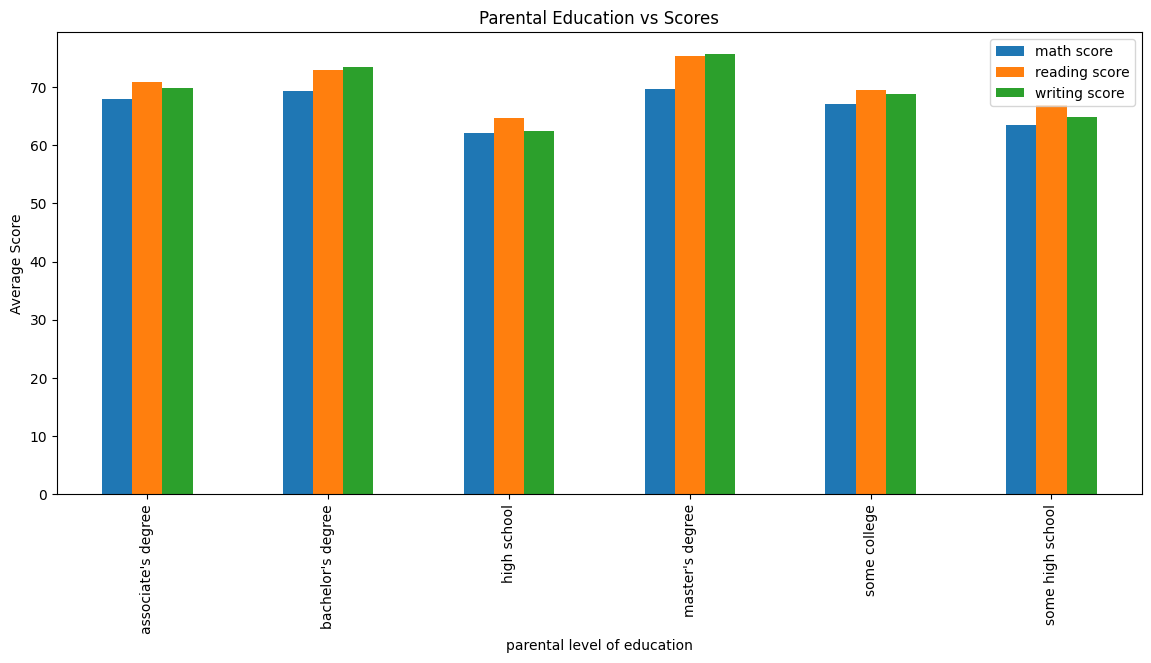

In [18]:
parent_scores = df.groupby('parental level of education')[score_cols].mean()

parent_scores.plot(kind='bar', figsize=(14,6))
plt.title("Parental Education vs Scores")
plt.ylabel("Average Score")
plt.show()

## Step 8 — Correlation Analysis

In [19]:
corr_matrix = df[score_cols].corr()
print(corr_matrix)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


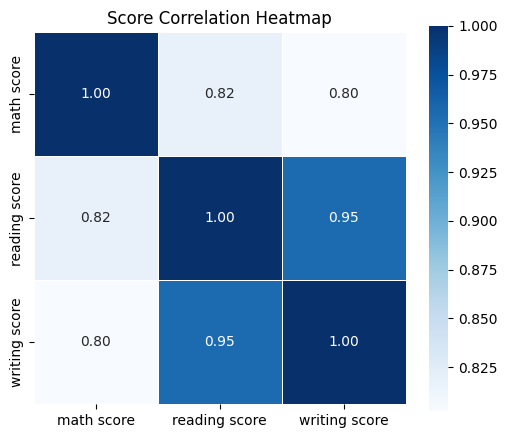

In [20]:
plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    square=True,
    linewidths=0.5
)

plt.title("Score Correlation Heatmap")
plt.show()

## Pearson Correlations

In [21]:
print("Math vs Reading:", df['math score'].corr(df['reading score']))
print("Reading vs Writing:", df['reading score'].corr(df['writing score']))

Math vs Reading: 0.817579663672055
Reading vs Writing: 0.9545980771462479


## Step 9 — Test Prep Impact Analysis

In [22]:
prep_groups = df.groupby('test preparation course')[score_cols].agg(['mean','std'])
print(prep_groups)

                        math score            reading score             \
                              mean        std          mean        std   
test preparation course                                                  
completed                69.695531  14.444699     73.893855  13.638384   
none                     64.077882  15.192376     66.534268  14.463885   

                        writing score             
                                 mean        std  
test preparation course                           
completed                   74.418994  13.375335  
none                        64.504673  14.999661  


## Boxplots

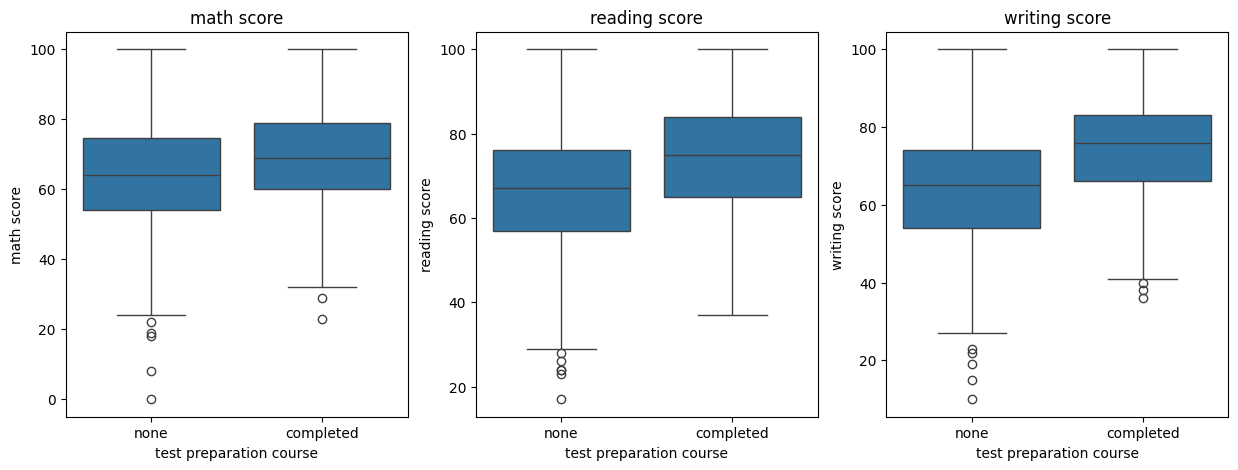

In [23]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

for i,col in enumerate(score_cols):
    sns.boxplot(data=df, x='test preparation course', y=col, ax=axes[i])
    axes[i].set_title(col)

plt.show()

## Improvement %

In [24]:
completed = df[df['test preparation course']=='completed'][score_cols].mean()
none = df[df['test preparation course']=='none'][score_cols].mean()

improvement = ((completed-none)/none)*100
print(improvement)

math score        8.766908
reading score    11.061348
writing score    15.369928
dtype: float64


## Step 10 — Gender Score Deep Dive

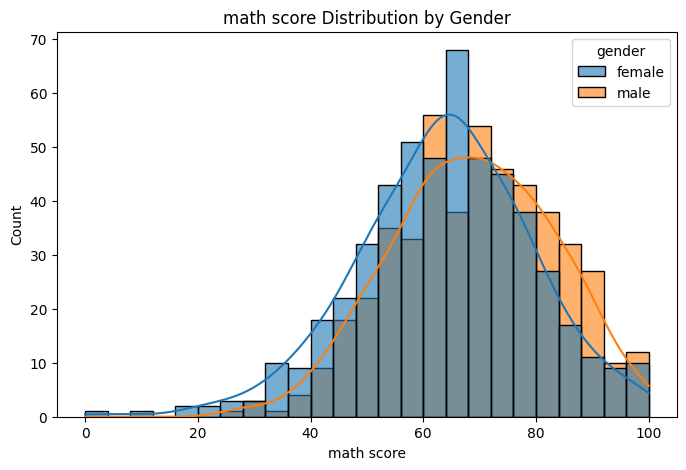

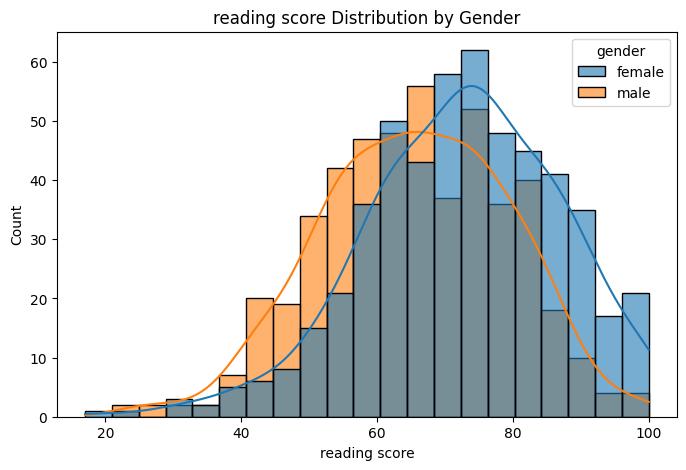

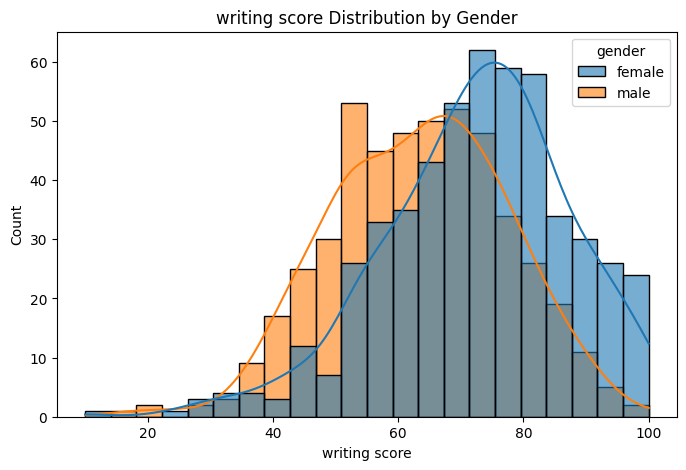

In [25]:
for col in score_cols:
    plt.figure(figsize=(8,5))
    
    sns.histplot(
        data=df,
        x=col,
        hue='gender',
        alpha=0.6,
        kde=True
    )
    
    plt.title(f"{col} Distribution by Gender")
    plt.show()

## Above 70 Analysis

In [26]:
result = {}

for subject in score_cols:
    temp = df.groupby('gender')[subject].apply(
        lambda x: (x>70).mean()*100
    )
    result[subject] = temp

gender_summary = pd.DataFrame(result)
print(gender_summary)

        math score  reading score  writing score
gender                                          
female   32.818533      58.301158      58.108108
male     45.850622      38.381743      32.157676


## Step 11 — Feature Engineering

In [27]:
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

df['average_score'] = df['total_score']/3

## Performance Grade

In [28]:
def grade(avg):
    if avg >= 80:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'F'

df['performance_grade'] = df['average_score'].apply(grade)

## High Achiever

In [29]:
df['high_achiever'] = df['average_score'] >= 80

## Lowest Subject

In [30]:
df['lowest_subject'] = df[score_cols].idxmin(axis=1)

print(df.head(10))

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2               

In [31]:
print(df['performance_grade'].value_counts())
print(df['lowest_subject'].value_counts())

performance_grade
B    261
C    256
A    198
D    182
F    103
Name: count, dtype: int64
lowest_subject
math score       552
writing score    292
reading score    156
Name: count, dtype: int64


## Step 12 — Pair Plot

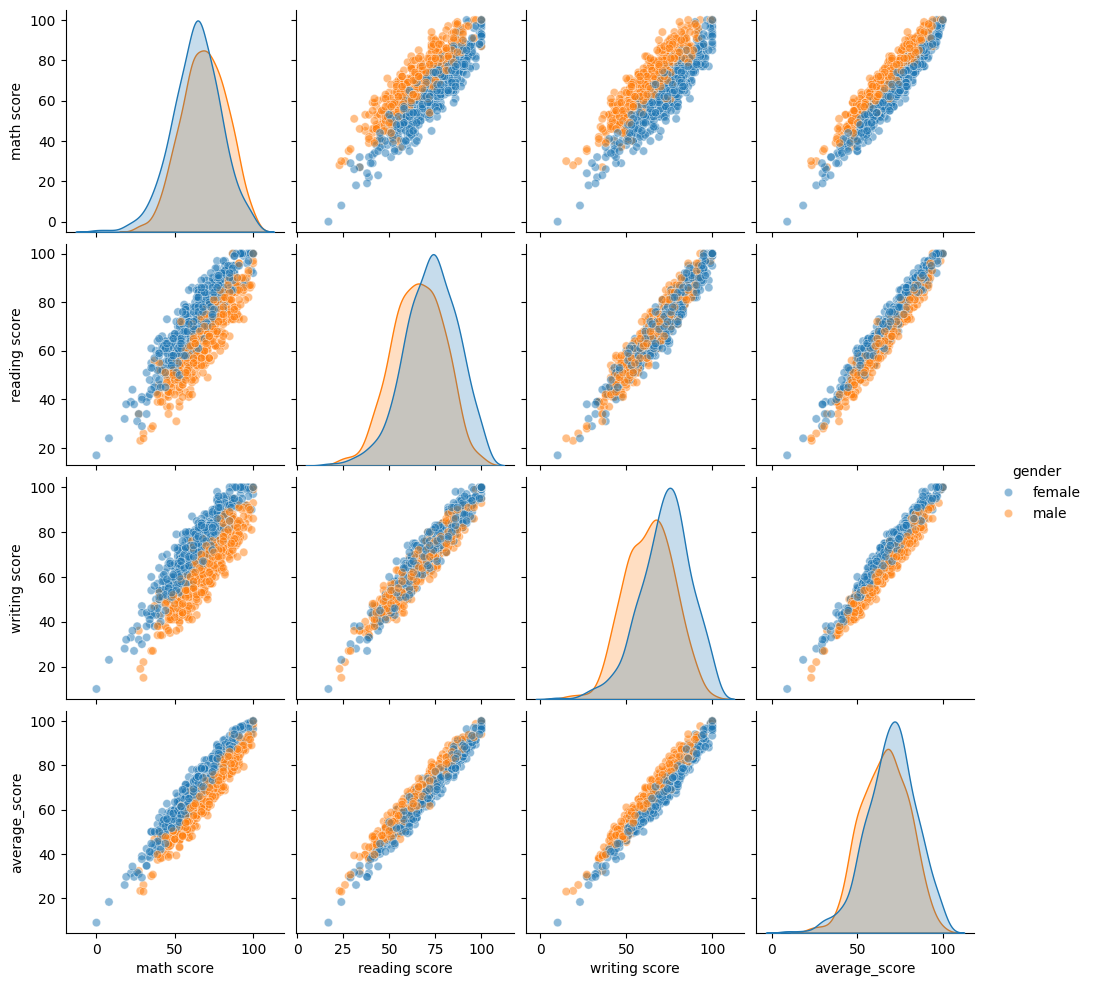

In [32]:
sns.pairplot(
    df[['math score','reading score','writing score','average_score','gender']],
    hue='gender',
    plot_kws={'alpha':0.5}
)

plt.savefig("pairplot_scores.png", dpi=150)
plt.show()

## Grade Pairplot

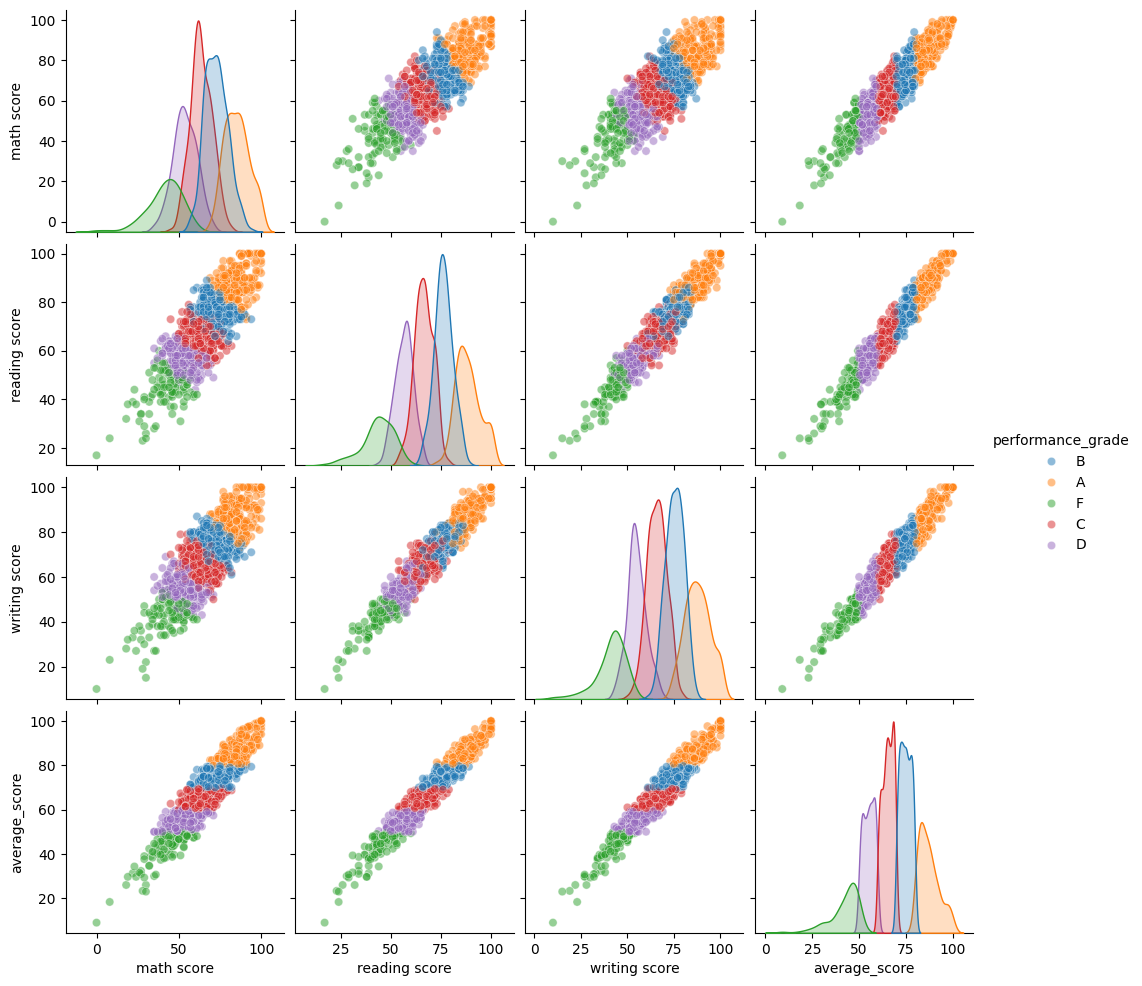

In [33]:
sns.pairplot(
    df[['math score','reading score','writing score','average_score','performance_grade']],
    hue='performance_grade',
    plot_kws={'alpha':0.5}
)

plt.savefig("pairplot_grades.png", dpi=150)
plt.show()

## Step 13 — Pivot Tables

In [34]:
pivot1 = pd.pivot_table(
    df,
    values='average_score',
    index='parental level of education',
    columns='gender',
    aggfunc='mean'
).round(2)

print(pivot1)

gender                       female   male
parental level of education               
associate's degree            71.12  67.87
bachelor's degree             74.67  68.78
high school                   64.75  61.58
master's degree               73.65  73.52
some college                  71.00  65.72
some high school              65.56  64.64


## Heatmap

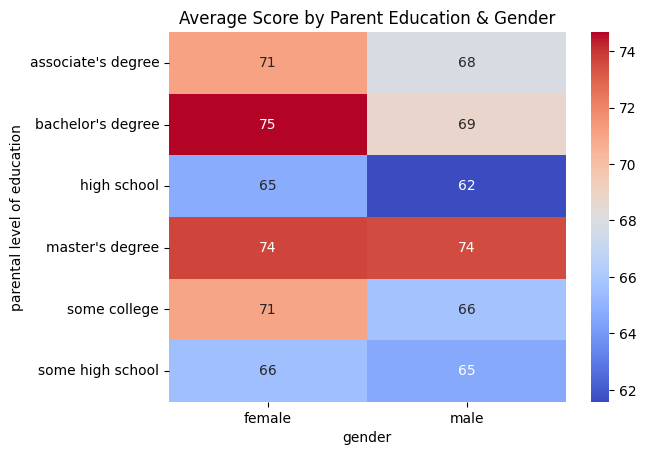

In [35]:
sns.heatmap(pivot1, annot=True, cmap='coolwarm')
plt.title("Average Score by Parent Education & Gender")
plt.show()

## Second Pivot

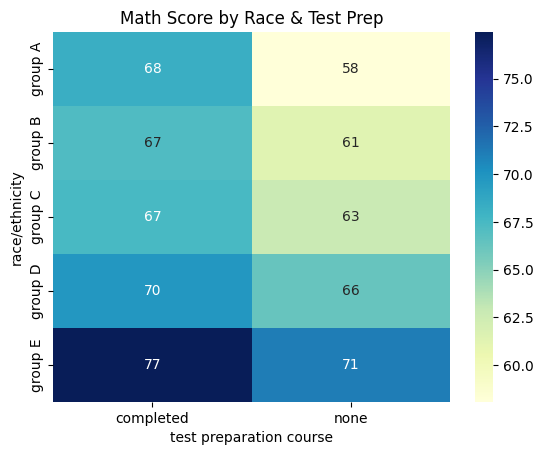

In [36]:
pivot2 = pd.pivot_table(
    df,
    values='math score',
    index='race/ethnicity',
    columns='test preparation course',
    aggfunc='mean'
)

sns.heatmap(pivot2, annot=True, cmap='YlGnBu')
plt.title("Math Score by Race & Test Prep")
plt.show()

## Step 14 — Reusable Functions

###  Function 1

In [37]:
def score_summary(df, col):
    """
    Returns summary statistics for a score column
    """
    return {
        "mean": df[col].mean(),
        "median": df[col].median(),
        "std": df[col].std(),
        "min": df[col].min(),
        "max": df[col].max(),
        "pct_above_70": (df[col]>70).mean()*100
    }

print(score_summary(df, 'math score'))

{'mean': np.float64(66.089), 'median': 66.0, 'std': 15.163080096009468, 'min': 0, 'max': 100, 'pct_above_70': np.float64(39.1)}


### Function 2

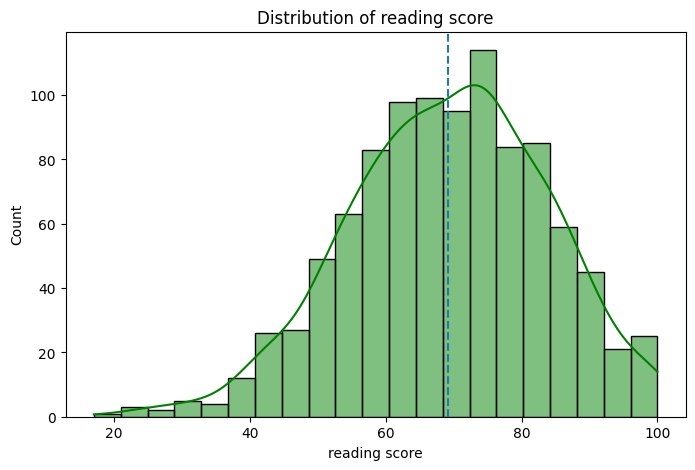

In [38]:
def plot_distribution(df, col, color):
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True, color=color)
    plt.axvline(df[col].mean(), linestyle='--')
    plt.title(f"Distribution of {col}")
    plt.show()

plot_distribution(df, 'reading score', 'green')

### Function 3

In [39]:
def compare_groups(df, group_col, score_col):
    result = df.groupby(group_col)[score_col].agg(['mean'])
    result['pct_above_70'] = df.groupby(group_col)[score_col].apply(
        lambda x: (x>70).mean()*100
    )
    return result.sort_values('mean', ascending=False)

print(compare_groups(df, 'gender', 'writing score'))

             mean  pct_above_70
gender                         
female  72.467181     58.108108
male    63.311203     32.157676


## Step 15 — NumPy Manual Statistical Computations

In [40]:
math_arr = df['math score'].values
read_arr = df['reading score'].values
write_arr = df['writing score'].values

### Basic Stats

In [41]:
for arr,name in zip([math_arr,read_arr,write_arr],
                    ['Math','Reading','Writing']):
    
    print(name)
    print("Mean:", np.mean(arr))
    print("Median:", np.median(arr))
    print("Std:", np.std(arr))
    print("Variance:", np.var(arr))
    print("Min:", np.min(arr))
    print("Max:", np.max(arr))
    print()

Math
Mean: 66.089
Median: 66.0
Std: 15.155496659628149
Variance: 229.68907899999996
Min: 0
Max: 100

Reading
Mean: 69.169
Median: 70.0
Std: 14.592890015346516
Variance: 212.95243900000003
Min: 17
Max: 100

Writing
Mean: 68.054
Median: 69.0
Std: 15.188057281956768
Variance: 230.677084
Min: 10
Max: 100



### Z-score Analysis

In [42]:
for arr,name in zip([math_arr,read_arr,write_arr],
                    ['Math','Reading','Writing']):
    
    z = (arr-np.mean(arr))/np.std(arr)
    
    print(name)
    print("Z > 2:", np.sum(z>2))
    print("Z < -2:", np.sum(z<-2))

Math
Z > 2: 19
Z < -2: 27
Reading
Z > 2: 20
Z < -2: 26
Writing
Z > 2: 18
Z < -2: 24


### Percentiles Table

In [43]:
percentiles = [10,25,50,75,90]

table = pd.DataFrame({
    "Math": np.percentile(math_arr, percentiles),
    "Reading": np.percentile(read_arr, percentiles),
    "Writing": np.percentile(write_arr, percentiles)
}, index=percentiles)

print(table)

    Math  Reading  Writing
10  47.0     51.0    48.00
25  57.0     59.0    57.75
50  66.0     70.0    69.00
75  77.0     79.0    79.00
90  86.0     87.1    87.00


### Top 10 Math Scorers

In [44]:
top10 = np.argsort(math_arr)[-10:]
print(top10)

[263 114 306 623 149 962 625 916 458 451]


### Pass Rate

In [45]:
for arr,name in zip([math_arr,read_arr,write_arr],
                    ['Math','Reading','Writing']):
    
    pass_rate = np.mean(arr>70)*100
    print(f"{name} Pass Rate: {pass_rate:.2f}%")

Math Pass Rate: 39.10%
Reading Pass Rate: 48.70%
Writing Pass Rate: 45.60%


## Step 16 — Professional 6-Chart Dashboard

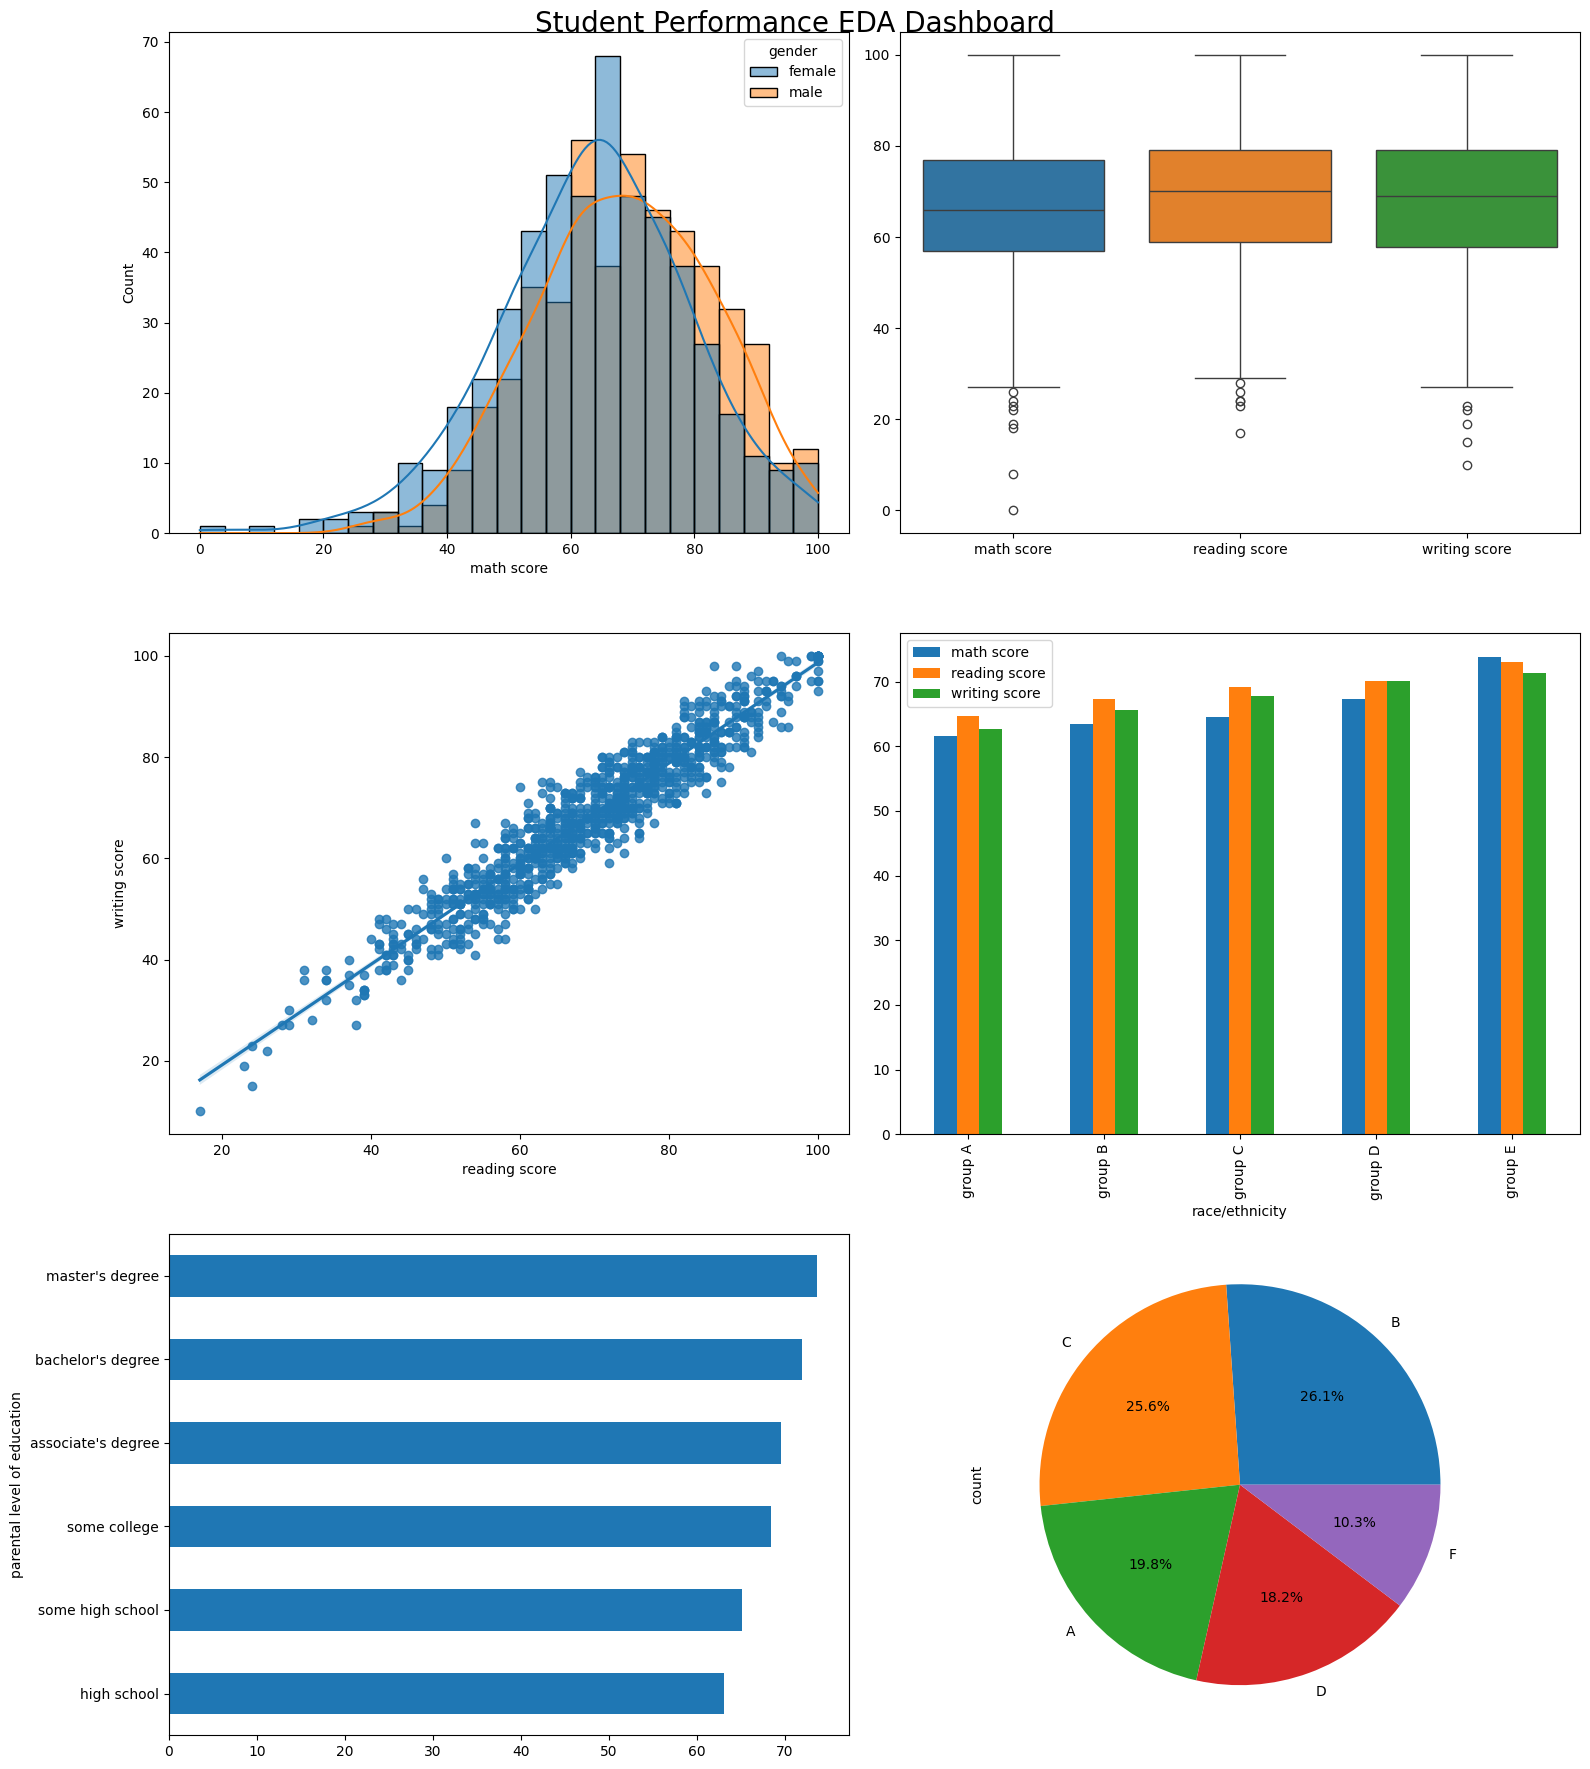

In [46]:
fig, axes = plt.subplots(3,2, figsize=(16,18))

# 1
sns.histplot(data=df, x='math score', hue='gender', kde=True, ax=axes[0,0])

# 2
sns.boxplot(data=df[score_cols], ax=axes[0,1])

# 3
sns.regplot(data=df, x='reading score', y='writing score', ax=axes[1,0])

# 4
df.groupby('race/ethnicity')[score_cols].mean().plot(
    kind='bar',
    ax=axes[1,1]
)

# 5
df.groupby('parental level of education')['average_score'].mean().sort_values().plot(
    kind='barh',
    ax=axes[2,0]
)

# 6
df['performance_grade'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[2,1]
)

plt.suptitle("Student Performance EDA Dashboard", fontsize=20)
plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=150)
plt.show()

## 1. Executive Summary

This project analyzed the Students Performance in Exams dataset, which contains records of 1,000 students and 8 features, including demographic information and academic scores in math, reading, and writing. The main objective was to understand how factors such as gender, parental education, lunch type, race/ethnicity, and test preparation influence student performance.

The analysis showed that students performed best in reading (average = 69.17), followed by writing (average = 68.05), while math had the lowest average score (66.09). Students who completed the test preparation course scored significantly higher across all subjects. Reading and writing scores were also highly correlated (0.95 correlation), showing that students strong in one language subject often perform well in the other. Feature engineering helped identify high achievers and overall performance grades for better educational insights.

## 2. Data Quality Assessment

The dataset was very clean and well-structured. It contained 1,000 rows and 8 columns, and no missing values were found in any column. Missing value percentage for all columns was 0%, which means no imputation or data cleaning was required.

Duplicate analysis also showed 0 duplicate records, indicating strong data quality. The dataset included 5 categorical columns and 3 numerical columns, and all data types were correctly assigned. For machine learning tasks, categorical variables would need encoding techniques such as One-Hot Encoding or Label Encoding before model training.

Overall, this dataset is highly suitable for exploratory data analysis and predictive modeling.

## 3. Key Statistical Findings

The descriptive statistics revealed important academic trends among students. The average scores were:

Math Score: 66.09
Reading Score: 69.17
Writing Score: 68.05

Math had the lowest average score, suggesting it may be the most challenging subject for students. It also had the largest score range (0 to 100), showing extreme performance variation.

Reading and writing performed better overall. Writing also showed high variability with a standard deviation of approximately 15.19, while math had a standard deviation of 15.16.

Students who completed the test preparation course improved their performance significantly:

Math improved by 8.77%
Reading improved by 11.06%
Writing improved by 15.37%

This indicates that test preparation has a strong positive impact, especially in writing.

## 4. Visualization Insights

The visualizations revealed several meaningful patterns. Histograms showed that student scores followed approximately normal distributions, with some low-performing outliers visible in math.

The correlation heatmap showed a very strong relationship between reading and writing scores (0.954 correlation), while math had slightly weaker correlations with both subjects.

Gender analysis showed interesting trends:

Male students scored above 70:
Math: 45.85%
Reading: 38.38%
Writing: 32.16%
Female students scored above 70:
Math: 32.82%
Reading: 58.30%
Writing: 58.11%

This shows males performed better in math, while females significantly outperformed males in reading and writing.

Bar charts also showed that students whose parents had higher education levels generally achieved better academic results.

## 5. Feature Engineering Rationale

Several new features were created to improve the dataset for deeper analysis and future machine learning applications.

total_score

This feature combines math, reading, and writing scores to measure overall academic performance.

average_score

This provides a normalized academic score for easier comparison between students.

performance_grade

Students were categorized into grades:

A = 80+
B = 70+
C = 60+
D = 50+
F = Below 50

This simplifies performance interpretation.

high_achiever

This identifies students scoring above 80 average and helps detect top-performing students.

lowest_subject

This identifies the weakest subject for each student and helps educators provide targeted support.

These engineered features make the dataset more useful for predictive modeling.

## 6. Actionable Recommendations for Educators

Based on the findings, several actions can improve student outcomes.

First, schools should expand access to test preparation programs because students who completed them performed significantly better across all subjects.

Second, math requires additional academic support because it had the lowest average score and highest difficulty level. Schools should offer extra tutoring sessions for struggling students.

Third, female students performed much better in reading and writing, while males performed better in math. Schools should investigate teaching methods that can reduce these subject-specific performance gaps.

Additionally, parental education showed a strong influence on student performance. Schools should involve parents through workshops and awareness programs to improve student support at home.

Finally, early identification of weak students through performance grading systems can help prevent long-term academic struggles.

## 7. Reflection & Lessons Learned

This project helped me strengthen my practical skills in Python, NumPy, Pandas, Matplotlib, and Seaborn. I learned how to perform complete exploratory data analysis, including data loading, cleaning, visualization, statistical analysis, and feature engineering.

I also learned how demographic factors can influence student academic performance and how machine learning-ready datasets are prepared.

The project improved my understanding of correlations, group comparisons, pivot tables, reusable functions, and NumPy statistical operations.

Most importantly, I learned how data analysis can generate meaningful educational insights that help institutions make better decisions for student success.